In [2]:
# Преоразовать существующий код для распознавания последовательности рукописных символов в текст.
# Написать генератор произвольной последовательности рукописных символов.

# ГЕНЕРАЦИЯ НАБОРА ДАННЫХ
# Сгенерировать набор текстовых строк из допустимых символов.
# Каждому набору поставить в соотвествие массив изоражений соответствующих символов.
# Добавить пробелы для разделения слов, символы пробелов не использовать во время классификации.


# КЛАССИФИКАЦИЯ (k ближайших соседей) (пример AIM practice 2)
# Часть символов оставить для обучения классификатора . Остальные  классифицировать
# по аналогии с примером mnist с прошлого занятия. Т.е. преобразовывать изображение в вектор.
# Выбрать оптимальный классификатор в зависимости от k- количество соседей.
# Метрика для измерения точности классификации, и выбора оптимального классификатора относительно параметра k - accuracy.

# РАСПОЗНАВАНИЕ
# заменить inf_net на последовательное применение следующих шагов:
# 1. генерация изображения с последовательностью символов
# 2. Выделение объектов оставляете как есть.
# 3. Примернить k-nn для решения задачи классификации. 
# 4. Вывести результат

In [10]:



import zipfile, io, random
from collections import defaultdict

import numpy as np
import cv2
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


In [11]:
ZIP_PATH = "data.zip"   # если лежит рядом с ноутбуком
zf = zipfile.ZipFile(ZIP_PATH, "r")

# Собираем список файлов по меткам (папкам)
files_by_label = defaultdict(list)
for name in zf.namelist():
    if name.endswith(".jpg") and "/" in name:
        lbl = name.split("/")[0]
        files_by_label[lbl].append(name)

labels = sorted(files_by_label.keys())
labels


['(',
 ')',
 '+',
 ',',
 '-',
 '0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 'X',
 'h',
 't',
 'times',
 'w',
 'y']

In [12]:
# times -> '×' в тексте
label_to_char = {lbl: ('×' if lbl == 'times' else lbl) for lbl in labels}
char_to_label = {v: k for k, v in label_to_char.items()}

allowed_chars = list(label_to_char.values())
allowed_chars


['(',
 ')',
 '+',
 ',',
 '-',
 '0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 'X',
 'h',
 't',
 '×',
 'w',
 'y']

In [13]:
def preprocess_char(gray_img: np.ndarray) -> np.ndarray:
    """
    Вход: серое изображение символа (обычно 45x45, но можно и другое)
    Выход: 45x45, фон=0, "чернила"=255, центрировано
    """
    img = gray_img.astype(np.uint8)

    # Otsu
    _, th = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Приводим к виду: символ белый (255), фон черный (0)
    if th.mean() > 127:
        th = 255 - th

    ys, xs = np.where(th > 0)
    if len(xs) == 0:
        return np.zeros((45, 45), dtype=np.uint8)

    x0, x1 = xs.min(), xs.max() + 1
    y0, y1 = ys.min(), ys.max() + 1
    crop = th[y0:y1, x0:x1]

    h, w = crop.shape
    scale = 40 / max(h, w)
    nh = max(1, int(round(h * scale)))
    nw = max(1, int(round(w * scale)))
    crop_rs = cv2.resize(crop, (nw, nh), interpolation=cv2.INTER_AREA)

    canvas = np.zeros((45, 45), dtype=np.uint8)
    yoff = (45 - nh) // 2
    xoff = (45 - nw) // 2
    canvas[yoff:yoff+nh, xoff:xoff+nw] = crop_rs
    return canvas


def read_symbol_from_zip(zf, filename: str) -> np.ndarray:
    data = zf.read(filename)
    img = Image.open(io.BytesIO(data)).convert("L")
    return np.array(img, dtype=np.uint8)


def sample_char_image(zf, files_by_label, label: str, rng: random.Random) -> np.ndarray:
    fn = rng.choice(files_by_label[label])
    img = read_symbol_from_zip(zf, fn)
    return preprocess_char(img)


In [14]:
def random_text(rng: random.Random, n_words=3, word_len_range=(3, 6), alphabet=None) -> str:
    """
    Генерация строки из допустимых символов.
    Пробелы используются ТОЛЬКО как разделители слов (не класс).
    """
    if alphabet is None:
        alphabet = allowed_chars

    words = []
    for _ in range(n_words):
        L = rng.randint(word_len_range[0], word_len_range[1])
        words.append("".join(rng.choice(alphabet) for _ in range(L)))
    return " ".join(words)


def generate_sequence_image(zf, files_by_label, text: str, rng=None,
                            gap=8, space_gap=35, v_jitter=3, canvas_h=60) -> np.ndarray:
    """
    Склеиваем символы в одну строку-картинку.
    Важно: пробелы делаем как увеличенный разрыв (space_gap), отдельного класса "space" нет.
    """
    if rng is None:
        rng = random.Random()

    symbols = []
    for ch in text:
        if ch == " ":
            symbols.append(None)
        else:
            lbl = char_to_label.get(ch, ch)
            symbols.append(sample_char_image(zf, files_by_label, lbl, rng))

    # ширина холста
    w = 1
    for im, ch in zip(symbols, text):
        if ch == " ":
            w += space_gap
        else:
            w += im.shape[1] + gap

    canvas = np.zeros((canvas_h, w), dtype=np.uint8)

    x = 0
    for im, ch in zip(symbols, text):
        if ch == " ":
            x += space_gap
            continue

        y0 = (canvas_h - im.shape[0]) // 2 + rng.randint(-v_jitter, v_jitter)
        y0 = max(0, min(canvas_h - im.shape[0], y0))

        canvas[y0:y0+im.shape[0], x:x+im.shape[1]] = np.maximum(
            canvas[y0:y0+im.shape[0], x:x+im.shape[1]], im
        )
        x += im.shape[1] + gap

    return canvas


In [15]:
def build_knn_dataset(zf, files_by_label, labels, n_per_class=400, seed=0):
    """
    Берём n_per_class примеров каждого класса, приводим к 45x45,
    превращаем в вектор признаков (бинарный 0/1), формируем X,y.
    """
    rng = random.Random(seed)
    X, y = [], []

    for lbl in labels:
        files = files_by_label[lbl]
        take = rng.sample(files, min(n_per_class, len(files)))

        for fn in take:
            img = read_symbol_from_zip(zf, fn)
            proc = preprocess_char(img)

            feat = (proc > 0).astype(np.uint8).reshape(-1)
            X.append(feat)
            y.append(lbl)

    return np.stack(X), np.array(y)


X, y = build_knn_dataset(zf, files_by_label, labels, n_per_class=300, seed=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

ks = list(range(1, 16, 2))  # 1,3,5,...,15
accs = {}

for k in ks:
    clf = KNeighborsClassifier(n_neighbors=k, metric="manhattan", weights="distance")
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    accs[k] = accuracy_score(y_test, pred)

best_k = max(accs, key=accs.get)
best_k, accs[best_k]


(1, 0.5993650793650793)

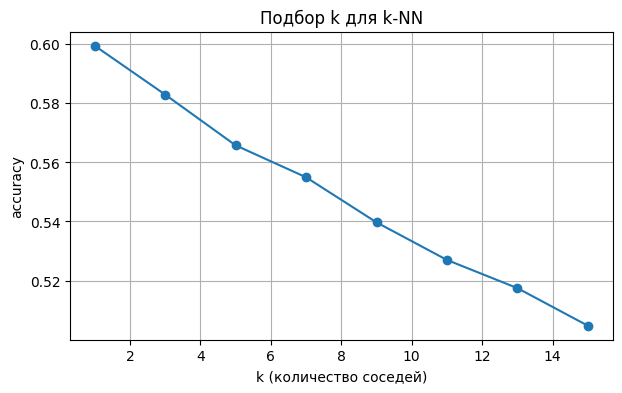

In [16]:
plt.figure(figsize=(7,4))
plt.plot(list(accs.keys()), list(accs.values()), marker="o")
plt.xlabel("k (количество соседей)")
plt.ylabel("accuracy")
plt.title("Подбор k для k-NN")
plt.grid(True)
plt.show()


In [17]:
knn = KNeighborsClassifier(n_neighbors=best_k, metric="manhattan", weights="distance")
knn.fit(X_train, y_train)
print("Best k =", best_k, "accuracy =", accs[best_k])


Best k = 1 accuracy = 0.5993650793650793


In [18]:
def segment_characters(seq_img: np.ndarray, min_area=25):
    """
    Вход: изображение строки (фон 0, символы 255)
    Выход: boxes (x,y,w,h) отсортированные слева направо, и crops 45x45
    """
    img = seq_img.astype(np.uint8)

    _, th = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    num, cc, stats, _ = cv2.connectedComponentsWithStats((th > 0).astype(np.uint8), connectivity=8)

    boxes = []
    for i in range(1, num):
        x, y, w, h, area = stats[i]
        if area >= min_area:
            boxes.append((x, y, w, h))

    boxes = sorted(boxes, key=lambda b: b[0])

    crops = []
    for x, y, w, h in boxes:
        crop = th[y:y+h, x:x+w]
        crop45 = cv2.resize(crop, (45, 45), interpolation=cv2.INTER_AREA)
        crops.append(preprocess_char(crop45))

    return th, boxes, crops


def recognize_sequence(seq_img: np.ndarray, knn: KNeighborsClassifier, gap_factor=1.8):
    """ gap_factor — порог для вставки пробела: если разрыв между bbox слишком большой. """
    th, boxes, crops = segment_characters(seq_img)

    if len(boxes) == 0:
        return "", th, boxes, crops

    X = np.stack([(c > 0).astype(np.uint8).reshape(-1) for c in crops])
    pred_lbl = knn.predict(X)
    pred_chars = [label_to_char[l] for l in pred_lbl]

    ws = [b[2] for b in boxes]
    median_w = np.median(ws) if ws else 20

    out = pred_chars[0]
    for i in range(1, len(boxes)):
        x_prev, _, w_prev, _ = boxes[i-1]
        x_cur, _, _, _ = boxes[i]
        gap = x_cur - (x_prev + w_prev)
        if gap > gap_factor * median_w:
            out += " "
        out += pred_chars[i]

    return out, th, boxes, crops


GT:    -7y)+ 6×) )+88
PRED:  w7,0+ -X0 -+-5


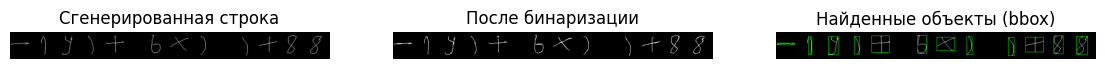

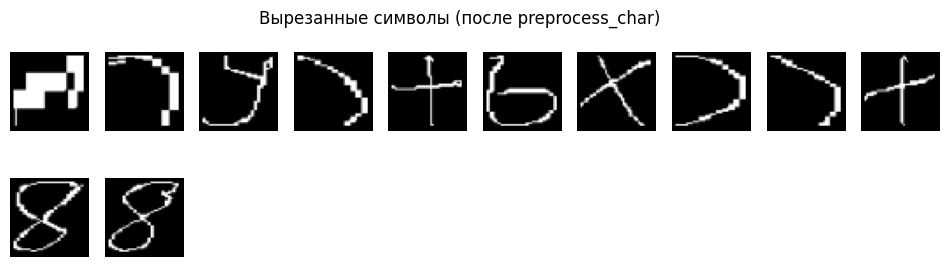

In [19]:
rng = random.Random(7)

text_gt = random_text(rng, n_words=3, word_len_range=(3, 6))
img_line = generate_sequence_image(zf, files_by_label, text_gt, rng=rng, gap=8, space_gap=40)

text_pred, th, boxes, crops = recognize_sequence(img_line, knn)

print("GT:   ", text_gt)
print("PRED: ", text_pred)

plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
plt.imshow(img_line, cmap="gray")
plt.title("Сгенерированная строка")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(th, cmap="gray")
plt.title("После бинаризации")
plt.axis("off")

vis = cv2.cvtColor(img_line, cv2.COLOR_GRAY2BGR)
for (x,y,w,h) in boxes:
    cv2.rectangle(vis, (x,y), (x+w, y+h), (0,255,0), 1)

plt.subplot(1,3,3)
plt.imshow(vis[..., ::-1])
plt.title("Найденные объекты (bbox)")
plt.axis("off")
plt.show()

nshow = min(20, len(crops))
plt.figure(figsize=(12,3))
for i in range(nshow):
    plt.subplot(2, 10, i+1)
    plt.imshow(crops[i], cmap="gray")
    plt.axis("off")
plt.suptitle("Вырезанные символы (после preprocess_char)")
plt.show()
